In [361]:
#Μέρος 2
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import IPython
import sounddevice as sd
import soundfile as sf
import librosa

In [362]:
#2.1
x_normalised, fs = librosa.load('music_dsp2026.wav', mono=True,sr=None)
x_normalised = x_normalised / np.max(np.abs(x_normalised))

#υπολογισμός κρουστικών αποκρίσεων
M = 32
L = 2*M
sqrt = np.sqrt(2/M)

n = np.arange(L)
h_k = []
g_k = []

for k in range(0, M):
    temp = np.sin((n+1/2)*np.pi/(2*M))*sqrt*np.cos((2*n+M+1)*(2*k+1)*np.pi/(4*M))
    h_k.append(temp)
    #inversing
    g_k.append(temp[::-1])

#ανάλυση και αποδεκατισμός
Tg = np.load("Tg_optimal.npy")
v_k_all = []
y_k_all = []
start = 0
end = 512
#loops για τον αριθμό των παραθύρων του αρχικού σήματος
for i in range(0, len(Tg[:,1])):
    v_k = []
    y_k = []
    for k in range(0,M):
        #filterbank
        temp = np.convolve(h_k[k], x_normalised[start:end], 'full')
        #decimation άνα Μ δείγματα κρατάω το 1
        y_k.append(temp[::M])
    #λόγω της παραθύρωσης
    start = end
    end += 512
    v_k_all.append(v_k)
    y_k_all.append(y_k)
#print(np.shape(y_k_all))
#print(np.shape(Tg))

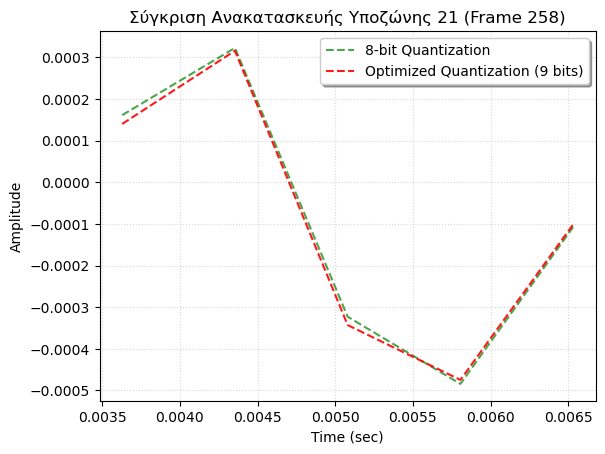

In [363]:
#2.2
y_k_quant_all = []
y_k_quant_8bit_all = []

bits_final_quant = 0;
bits_final_quant_8bit = 0;
y_k_quant_all = []
y_k_quant_8bit_all = []

#σταθερό βήμα μη προσαρμοσμένου κβαντιστή
delta_8bit =  1/(2**7)

flag = 1
for i in range(0, len(Tg[:,1])):
    y_k_quant = []
    y_k_quant_8bit = []
    for k in range(1, M+1):
        #κεντρική συχνότητα κάθε φίλτρου
        f_k = (2*k-1)*fs/L
        
        #αντιστοιχία στα k_bins των μασκών Τg, πολλαπλασιάζουμε με 256 κα΄θώς τα άλλα 256 για να φθάσουμε τα 512 αφορούν την συμμετρία του DFT
        bin_start = int((f_k - fs/L)*256/(fs))
        bin_end = int((f_k + fs/L)*256/(fs))
        
        #aριθμός των bit για την κωδικοποίηση των επιπέδων του κβαντιστή, παίρνει τιμές 8,9. Το 9 λαμβάνει συνήθως κοντά στην 20 ζώνη 
        b_k = int(16 - np.log2(np.min(Tg[i,bin_start:bin_end])) - 1)

        #υπολογισμός final bit rate, το επί δυο το βάζω λόγω stereo παρόλο που απλοποιείται
        bits_final_quant += len(y_k_all[i][k-1])*b_k*2
        bits_final_quant_8bit += len(y_k_all[i][k-1])*8*2

        #υπολογισμός του κβάντουμ και για προσαρμοσμένο
        y_k_maximum = np.max(y_k_all[i][k-1][:])
        y_k_minimum = np.min(y_k_all[i][k-1][:])        
        delta =  (y_k_maximum - y_k_minimum)/(2**b_k)
        quantized_idx = np.round((y_k_all[i][k-1] - y_k_minimum) / delta)
        
        #εύρη στο [-1,1] η είσοδος του μη προσαρμοσμένου κβαντιστή 
        temp = np.max(np.abs(y_k_all[i][k-1]))
        y_k_all[i][k-1] /= temp 
        quantized_idx_8bit = np.round((y_k_all[i][k-1] - y_k_minimum/temp) / delta_8bit)
        y_k_reconstructed = (quantized_idx * delta) + y_k_minimum
        y_k_reconstructed_8bit = (quantized_idx_8bit * delta_8bit) + y_k_minimum/temp
        
        #επανφορά από κανονικοποίηση
        y_k_reconstructed_8bit *= temp
        y_k_quant.append(y_k_reconstructed)
        y_k_quant_8bit.append(y_k_reconstructed_8bit)

        #διαφορά μεταξύ παραθύρων με επίπεδα των 9 και 8 bit
        if b_k == 9:
            #print(k-1, i)
            if i != 258:
                continue
            if i == 258 and flag == 1:
                flag = 0 #μπαίνει δύο φορές για το συγκεκριμένο παράθυρο
                #print(k-1) #k-1 = 21
                t = (M/fs) * np.arange(5, 10, 1)
                plt.figure()
                plt.plot(t, y_k_reconstructed_8bit[5:10], label='8-bit Quantization', linestyle='--', color='green', alpha=0.7)
                plt.plot(t, y_k_reconstructed[5:10], label='Optimized Quantization (9 bits)', linestyle='--', color='red', alpha=0.9)
                plt.title(f'Σύγκριση Ανακατασκευής Υποζώνης {k-1} (Frame {i})')
                plt.xlabel('Time (sec)')
                plt.ylabel('Amplitude')
                plt.legend(loc='best', frameon=True, shadow=True)
                plt.grid(True, linestyle=':', alpha=0.5)
                plt.show()
    y_k_quant_all.append(y_k_quant)
    y_k_quant_8bit_all.append(y_k_quant_8bit)

rate 0.43749224362598416
rate_8bit 0.4376690889535445


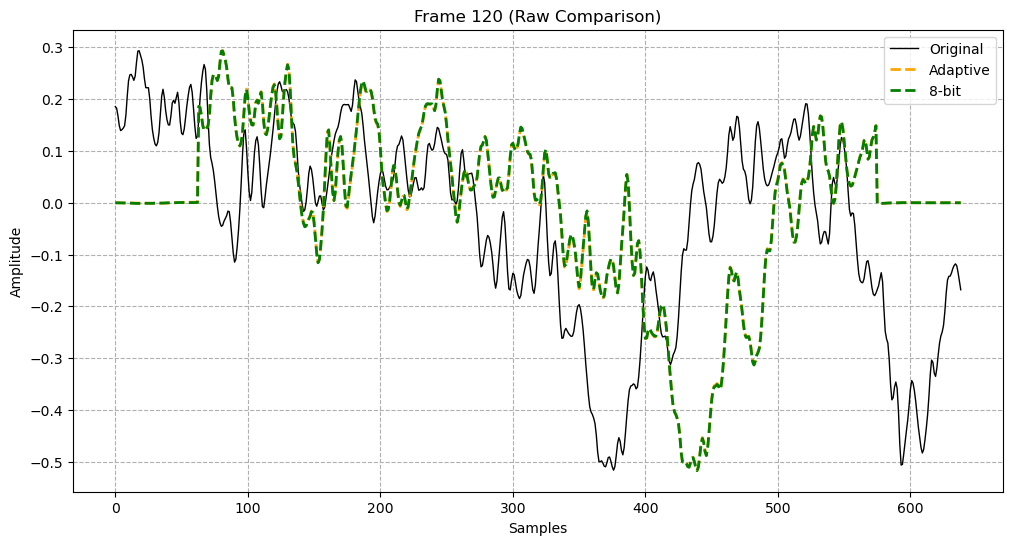

count is 63
MSE (Optimized): 2.8519788439779334e-06
MSE (8-bit):     3.318879116589393e-06


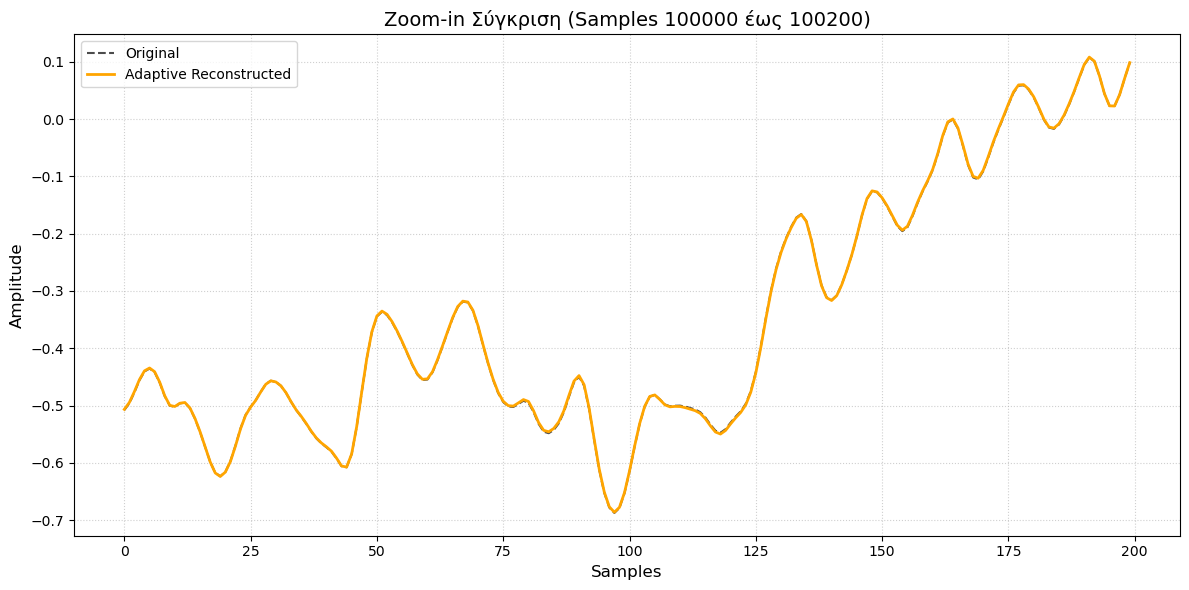

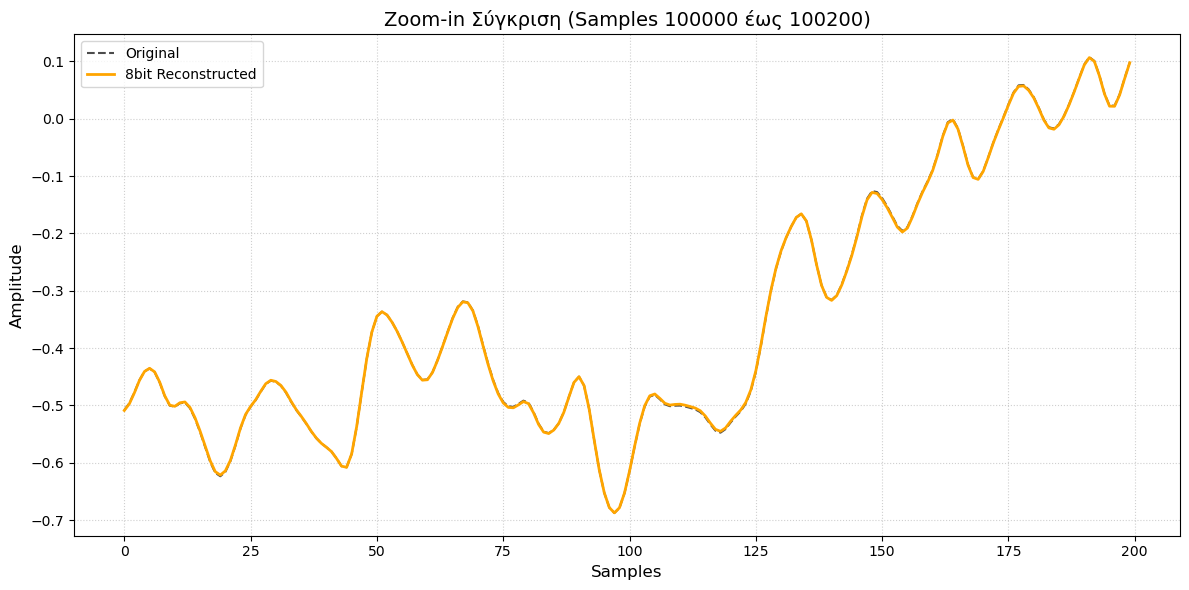

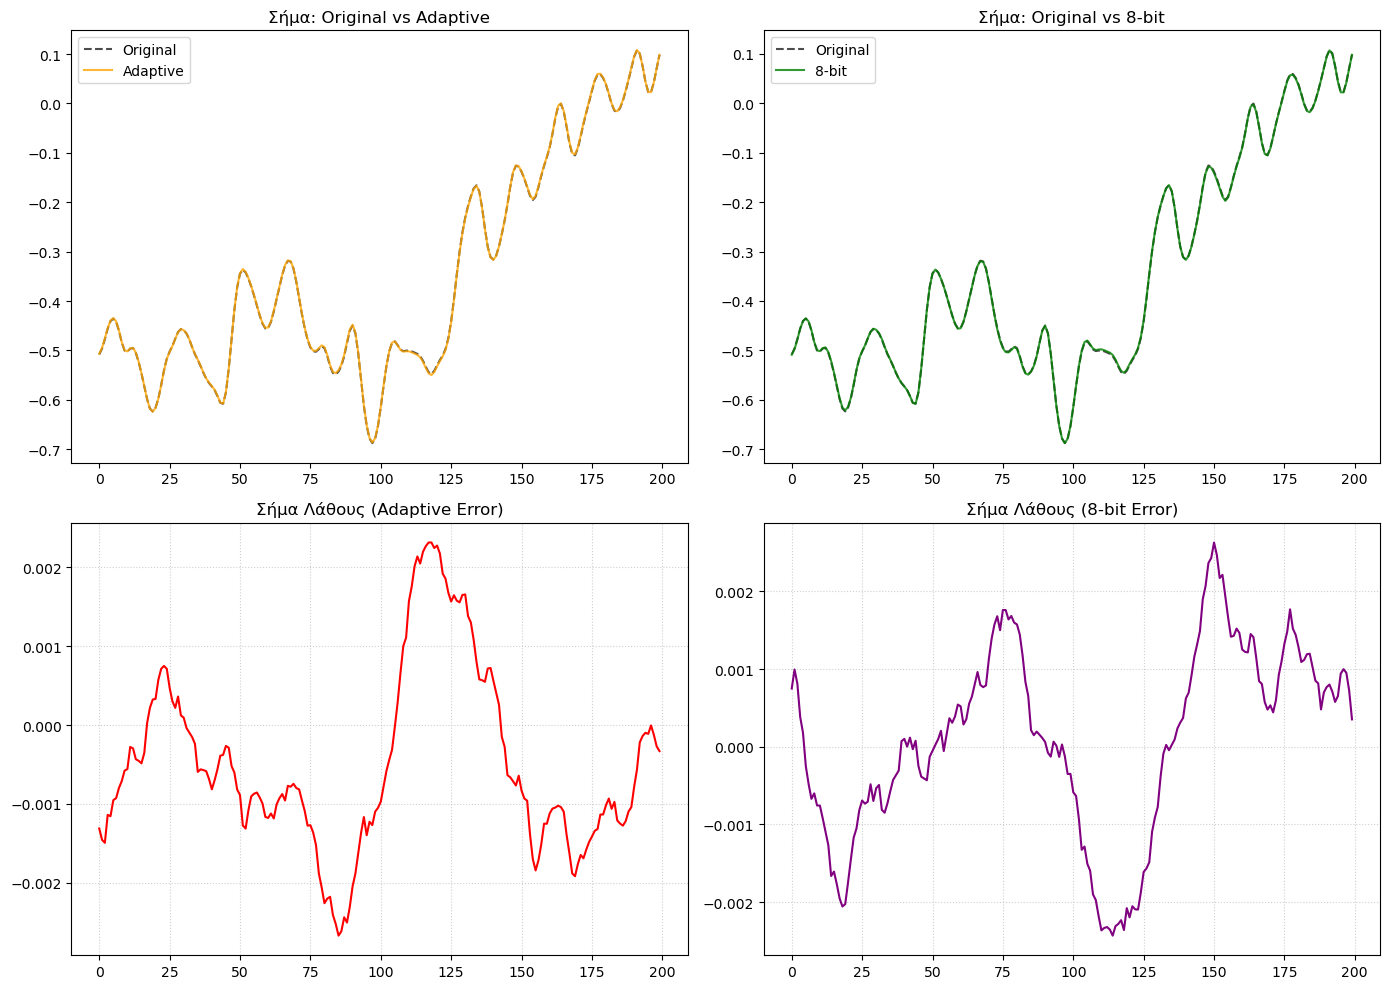

In [364]:
#2.3
w_k_all = [] 
w_k_8bit_all =[]

for i in range(0, len(Tg[:,1])):
    w_k = []
    w_k_8bit = []
    for k in range(0, M):
        #interpolation προσθέτουμε M-1 μηδενικά μεταξύ δειγμάτων άρα τελικό μέγεθος M*y_k_quant = M * 18
        temp = np.zeros(len(y_k_quant_all[i][k][:])+(M-1)*len(y_k_quant_all[i][k][:]))
        temp2 = np.zeros(len(y_k_quant_8bit_all[i][k][:])+(M-1)*len(y_k_quant_8bit_all[i][k][:]))
        temp[::M] = y_k_quant_all[i][k][::1]
        temp2[::M] = y_k_quant_8bit_all[i][k][::1]
        w_k.append(temp)
        w_k_8bit.append(temp2)
    w_k_all.append(w_k)
    w_k_8bit_all.append(w_k_8bit)

s_quant = []
s_quant_8bit = []
for i in range(0, len(Tg[:,1])):
    #639 = 18*32 + 64 - 1
    s_quant_frame = np.zeros(639)
    s_quant_8bit_frame = np.zeros(639)
    #και προσθέτουμε όλες τις εξόδους των φίλτρων για κάθε παράθυρο
    for k in range(0, M):
        s_quant_frame += np.convolve(w_k_all[i][k], g_k[k], 'full')
        s_quant_8bit_frame += np.convolve(w_k_8bit_all[i][k], g_k[k], 'full')
    s_quant.append(s_quant_frame)
    s_quant_8bit.append(s_quant_8bit_frame)
#print(np.shape(s_quant)))
#ΟLA
#λόγω των συνλίξεων τα παραθυροποιημένα σήματα βγαίνουν πιο μεγάλα κάτα 63 + 63 οπότε τα προσθέτουμε άνα hop και οι επικαλύψεις εξασφαλίζονται
#λόγω του += δηλαδή κάθε frame s είναι 639 δείγματα και η πρόσθεση του επόμενου frame ξεκινά από το 512 δείγμα * i
hop = 512 
num_frames = len(s_quant)
frame_len = len(s_quant[0]) 

total_len = (num_frames - 1) * hop + frame_len

final_audio_optimized = np.zeros(total_len)
final_audio_8bit = np.zeros(total_len)

for i in range(num_frames):
    start = i * hop
    end = start + frame_len
    
    final_audio_optimized[start:end] += s_quant[i]
    final_audio_8bit[start:end] += s_quant_8bit[i]


# 1. Normalization στο [-1, 1] για να αποφύγουμε το clipping
final_opt_norm = final_audio_optimized / np.max(np.abs(final_audio_optimized))
final_8bit_norm = final_audio_8bit / np.max(np.abs(final_audio_8bit))

# 2. Μετατροπή σε Stereo (L = R)
stereo_optimized = np.vstack((final_opt_norm, final_opt_norm)).T
stereo_8bit = np.vstack((final_8bit_norm, final_8bit_norm)).T

# 3. Αποθήκευση σε .wav
sf.write('music_adaptive_stereo.wav', stereo_optimized, fs)
sf.write('music_8bit_stereo.wav', stereo_8bit, fs)

#υπολογισμός compression rate
bits_initial = 2*len(x_normalised)*16
rate = 1 - bits_final_quant/bits_initial
rate_8bit = 1 - bits_final_quant_8bit/bits_initial

print("rate", rate)
print("rate_8bit", rate_8bit)

#τα συμπιεσμένα σήματα είναι μετατοπισμένα κατά 63 δείγματα
#για το Frame 120
frame_idx = 120
hop = 512

# Παίρνουμε τα δείγματα ακριβώς όπως είναι, χωρίς καμία μετατόπιση
start = frame_idx * hop
x_frame = x_normalised[start : start + 639] # Το αρχικό τμήμα
s_opt = s_quant[frame_idx]                 # Το βελτιστοποιημένο frame
s_8bit = s_quant_8bit[frame_idx]           # Το 8-bit frame

# Plot
plt.figure(figsize=(12, 6))

# Αρχικό σήμα (συνεχής γραμμή)
plt.plot(x_frame, label='Original', color='black', linewidth=1)

# Τα υπόλοιπα με διακεκομμένη (dashed) όπως ζήτησες
plt.plot(s_opt, label='Adaptive', linestyle='--', color='orange', linewidth=2)
plt.plot(s_8bit, label='8-bit', linestyle='--', color='green', linewidth=2)

plt.title(f'Frame {frame_idx} (Raw Comparison)')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

count = 0
while s_opt[count] < 10e-2:
    count+=1
print("count is",  count)

#υπολογισμός MSE
# The delay introduced by filter bank
delay = 63

#μετατοπίζουμε τα συμπιεσμένα σήματα κατά 63 δείγματα και δεν κάνουμε σύγκριση για τα τελευταία 63 καθώς τα έχουμε χάσει
max_comparable_length = min(len(x_normalised), len(final_audio_optimized) - delay)

x_aligned = x_normalised[:max_comparable_length]
opt_aligned = final_audio_optimized[delay : delay + max_comparable_length]
bit8_aligned = final_audio_8bit[delay : delay + max_comparable_length]

#MSE 
MSE_ERROR1 = np.mean((x_aligned - opt_aligned) ** 2)
MSE_ERROR2 = np.mean((x_aligned - bit8_aligned) ** 2)

print(f"MSE (Optimized): {MSE_ERROR1}")
print(f"MSE (8-bit):     {MSE_ERROR2}")

#Σωστή ευθυγράμμιση (Alignment) 
delay = 63
length = min(len(x_normalised), len(final_audio_optimized) - delay)

x_aligned = x_normalised[:length]
opt_aligned = final_audio_optimized[delay : delay + length]
bit8_aligned = final_audio_8bit[delay : delay + length]

#Δημιουργία των Axes
# Ορισμός του figure και του axes (ax2)
fig, ax2 = plt.subplots(figsize=(12, 6))

# Zoom σε 200 δείγματα
start_zoom = 100000
end_zoom = 100200

# Σχεδίαση των δεδομένων
ax2.plot(x_aligned[start_zoom:end_zoom], 'k--', label='Original', alpha=0.7)
ax2.plot(opt_aligned[start_zoom:end_zoom], 'orange', label='Adaptive Reconstructed', linewidth=2)
#Μορφοποίηση
ax2.set_title(f'Zoom-in Σύγκριση (Samples {start_zoom} έως {end_zoom})', fontsize=14)
ax2.set_xlabel('Samples', fontsize=12)
ax2.set_ylabel('Amplitude', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

fig, ax2 = plt.subplots(figsize=(12, 6))

# Zoom σε 200 δείγματα
start_zoom = 100000
end_zoom = 100200

# Σχεδίαση των δεδομένων
ax2.plot(x_aligned[start_zoom:end_zoom], 'k--', label='Original', alpha=0.7)
ax2.plot(bit8_aligned[start_zoom:end_zoom], 'orange', label='8bit Reconstructed', linewidth=2)
#Μορφοποίηση
ax2.set_title(f'Zoom-in Σύγκριση (Samples {start_zoom} έως {end_zoom})', fontsize=14)
ax2.set_xlabel('Samples', fontsize=12)
ax2.set_ylabel('Amplitude', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 1. Υπολογισμός του σήματος λάθους (error signal)
error_adaptive = x_aligned - opt_aligned
error_8bit = x_aligned - bit8_aligned

# 2. Επιλογή παραθύρου για οπτικοποίηση (χρησιμοποιώ το δικό σου zoom)
start_v = 100000
end_v = 100200 # λίγο μεγαλύτερο παράθυρο για να φαίνεται η δομή

plt.figure(figsize=(14, 10))

# --- Μέθοδος 1: Adaptive (Optimized) ---
plt.subplot(2, 2, 1)
plt.plot(x_aligned[start_v:end_v], 'k--', label='Original', alpha=0.7)
plt.plot(opt_aligned[start_v:end_v], 'orange', label='Adaptive', alpha=0.8)
plt.title('Σήμα: Original vs Adaptive')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(error_adaptive[start_v:end_v], 'red')
plt.title('Σήμα Λάθους (Adaptive Error)')
plt.grid(True, linestyle=':', alpha=0.6)

# --- Μέθοδος 2: 8-bit ---
plt.subplot(2, 2, 2)
plt.plot(x_aligned[start_v:end_v], 'k--', label='Original', alpha=0.7)
plt.plot(bit8_aligned[start_v:end_v], 'green', label='8-bit', alpha=0.8)
plt.title('Σήμα: Original vs 8-bit')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(error_8bit[start_v:end_v], 'purple')
plt.title('Σήμα Λάθους (8-bit Error)')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()